In [1]:
import ast
import os
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
bfont_path = "/usr/share/fonts/myFonts/arialbd.ttf"
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_prop_7 = FontProperties(fname=font_path, size=7)
font_name = font_prop.get_name()
ifont_prop = FontProperties(fname=ifont_path)
ifont_prop_7 = FontProperties(fname=ifont_path, size=7)
ifont_prop_6 = FontProperties(fname=ifont_path, size=6.5)
bfont_prop = FontProperties(fname=bfont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]

label = "pident_90"

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.makedirs(figure_fold, exist_ok=True)

In [3]:
from collections import defaultdict

# oriC/oriV
def get_ori_data(base_folder, genus_name, label):
    path = f'{base_folder}/statistics_records/{genus_name}/Ori_finder/ori_results.csv'
    df = pd.read_csv(path)
    cats = ['typical plasmid','intermediate replicon','typical chromosome']
    oric = df.groupby(f'category-{label}')['oriC(ORCA)'].agg(['count',lambda x:(x=='Y').sum()])
    oric.columns=['total','y']
    oric['pct'] = oric['y']/oric['total']*100
    oric = [oric.loc[c,'pct'] if c in oric.index else 0 for c in cats]
    vdf = df[df[f'category-{label}']!='typical chromosome']
    oriv = vdf.groupby(f'category-{label}')['oriV(OriV-Finder)'].agg(['count',lambda x:(x=='Y').sum()])
    oriv.columns=['total','y']
    oriv['pct'] = oriv['y']/oriv['total']*100
    oriv = [oriv.loc[c,'pct'] if c in oriv.index else 0 for c in ['typical plasmid','intermediate replicon']]
    return cats, oric, oriv

def plot_oriC(ax, data, cats):
    x = np.arange(len(cats))
    colors = ['#4472C4','#70AD47','#ED7D31']
    ax.bar(x, data, color=colors, width=0.6, alpha=0.8)
    ax.set_title('oriC', font=ifont_prop, pad=3)
    ax.set_ylabel('Replicon percentage (%)')
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize().replace('Intermediate replicon', 'IR') for c in cats])
    for lab in ax.get_xticklabels():
        if lab.get_text() != "IR":
            lab.set(rotation=30, ha="right", va="top", rotation_mode="anchor")
    ax.set_ylim(0,105)
    ax.set_xlim(-0.5,len(x)-0.5)

def plot_oriV(ax, data):
    x = np.arange(2)
    colors = ['#4472C4','#70AD47']
    ax.bar(x, data, color=colors, width=0.6, alpha=0.8)
    ax.set_title('oriV', font=ifont_prop, pad=3)
    ax.set_xticks(x)
    ax.set_xticklabels(['Typical plasmid','IR'])
    for lab in ax.get_xticklabels():
        if lab.get_text() != "IR":
            lab.set(rotation=30, ha="right", va="top", rotation_mode="anchor")
    ax.set_ylim(0,105)
    ax.set_xlim(-0.5,len(x)-0.5)

# gene content
def get_gene_data(base_folder, genus_name):
    def load(f): 
        return ast.literal_eval(open(f'{base_folder}/figure_data/gene_content/{genus_name}/{f}', encoding='utf-8').read().strip())
    t = load('typical plasmid.txt')
    tr= load('intermediate replicon.txt')
    c= load('typical chromosome.txt')
    def pct(d): 
        total=d['all']
        return {k:v/total*100 for k,v in d.items() if k!='all'}
    t,tr,c = pct(t),pct(tr),pct(c)
    genes = sorted(set(t)|set(tr)|set(c),key=lambda g:next((i for i,p in enumerate(['tra','par','sop','rep','dna'])if g.startswith(p)),99))
    def a(d): return [d.get(g,0) for g in genes]
    return genes, a(t),a(tr),a(c)

def plot_gene_content(ax, genes, t, tr, c, ifont_name):
    char_gene_pre = ['tra', 'par', 'sop', 'rep', 'dna']
    gene_priority = {pre: idx for idx, pre in enumerate(char_gene_pre)}

    def sort_key(gene):
        for pre in char_gene_pre:
            if gene.startswith(pre):
                return (gene_priority[pre], gene)
        return (len(char_gene_pre), gene)

    sorted_pairs = sorted(zip(genes, t, tr, c), key=lambda x: sort_key(x[0]))
    genes, t, tr, c = map(list, zip(*sorted_pairs)) if sorted_pairs else ([], [], [], [])
    
    x = np.arange(len(genes))
    w = 0.8/3
    ax.bar(x-w, t, w, label='Typical plasmid', color='#4472C4', alpha=0.8)
    ax.bar(x, tr, w, label='IR', color='#70AD47', alpha=0.8)
    ax.bar(x+w, c, w, label='Typical chromosome', color='#ED7D31', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(genes, rotation=45, ha='right', va='top', rotation_mode='anchor', fontfamily=ifont_name)
    ax.legend(loc='upper left')
    ax.set_ylim(0, 105)
    ax.set_xlim(-0.5, len(genes) - 0.5)

    color_map = {
        'rep': '#1B9E77',
        'tra': '#A6761D',
        'par': '#7570B3',
        'sop': '#7570B3',
        'dna': '#1B9E77',
    }
    gene_prefixes = ['rep', 'tra', 'par', 'sop', 'dna']
    for tick_label in ax.get_xticklabels():
        gene = tick_label.get_text()
        for pre in gene_prefixes:
            if gene.startswith(pre):
                tick_label.set_color(color_map[pre])
                break

    gene_indices = defaultdict(list)
    for idx, gene in enumerate(genes):
        for prefix in gene_prefixes:
            if gene.startswith(prefix):
                gene_indices[prefix].append(idx)
                break

    groups = [
        ('tra', '#A6761D', 'Plasmid transfer genes'),
        ('par_sop', '#7570B3', 'Partition genes'),
        ('rep_dna', '#1B9E77', 'Replication genes')
    ]

    y_top = ax.get_ylim()[1]
    rect_height = 5
    for prefix_group, color, label in groups:
        if prefix_group == 'tra':
            indices = gene_indices.get('tra', [])
        elif prefix_group == 'par_sop':
            indices = gene_indices.get('par', []) + gene_indices.get('sop', [])
        else:
            indices = gene_indices.get('rep', []) + gene_indices.get('dna', [])
        
        if not indices:
            continue
        left, right = min(indices) - 0.5, max(indices) + 0.5
        ax.add_patch(plt.Rectangle((left, y_top + 1), right-left, rect_height, 
                                   color=color, alpha=0.7, lw=0, clip_on=False))
        ax.text((left+right)/2, y_top + 1 + rect_height, label, 
                ha='center', va='bottom', fontsize=7, color=color)

    major_groups = [{'tra'}, {'par', 'sop'}, {'rep', 'dna'}]
    if len(genes) == 0:
        return
    
    prev_prefix = None
    prev_major_group = None
    for idx, gene in enumerate(genes):
        curr_prefix = None
        for p in gene_prefixes:
            if gene.startswith(p):
                curr_prefix = p
                break
        if not curr_prefix:
            continue

        curr_major_group = None
        for g in major_groups:
            if curr_prefix in g:
                curr_major_group = g
                break

        if idx == 0:
            prev_prefix = curr_prefix
            prev_major_group = curr_major_group
            continue

        x_line = idx - 0.5
        if curr_major_group != prev_major_group:
            ax.axvline(x=x_line, color='#707070', lw=1.0, linestyle='-', zorder=0)
        elif curr_prefix != prev_prefix:
            ax.axvline(x=x_line, color='#AAAAAA', lw=0.8, linestyle='--', zorder=0)
        else:
            ax.axvline(x=x_line, color='#DDDDDD', lw=0.5, linestyle=':', zorder=0)

        prev_prefix = curr_prefix
        prev_major_group = curr_major_group

In [4]:
import numpy as np
from scipy import stats

np.random.seed(42)

def GC_data(base_folder):
    all_data = []
    for genus_name in keep_genus:
        folder = f'{base_folder}/statistics_records/{genus_name}'
        os.chdir(folder)
        replicon_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
        replicon_data['genus'] = genus_name
        all_data.append(replicon_data)
    
    all_data = pd.concat(all_data, ignore_index=True)
    all_data['acc_n'] = all_data['accession'].str.split('-').str[0]
    all_data['GC_bases'] = all_data['size'] * all_data['GC_content']

    genome_gc_result = all_data.groupby('acc_n').agg(size_bp=('size', 'sum'), GC_bp=('GC_bases', 'sum')).reset_index()
    genome_gc_result['GC_content'] = genome_gc_result['GC_bp'] / genome_gc_result['size_bp']
    
    typ_pla = all_data[all_data['category-pident_90'] == 'typical plasmid'][['accession', 'acc_n', 'category-pident_90', 'GC_content', 'genus']]
    tra_rep = all_data[all_data['category-pident_90'] == 'intermediate replicon'][['accession', 'acc_n', 'category-pident_90', 'GC_content', 'genus']]
    
    tpy_MS = pd.merge(typ_pla, genome_gc_result[['acc_n', 'GC_content']], on='acc_n', how='left')
    tra_MS = pd.merge(tra_rep, genome_gc_result[['acc_n', 'GC_content']], on='acc_n', how='left')

    all_frag_data = []
    for genus_name in keep_genus:
        folder = f'{base_folder}/kmer_chr_frag_samples/{genus_name}'
        os.chdir(folder)
        frag_data = pd.read_csv('chromosome_fragment_data.tsv', sep='\t')
        frag_data['genus'] = genus_name
        all_frag_data.append(frag_data)
    
    all_frag_data = pd.concat(all_frag_data, ignore_index=True)
    all_frag_data['acc_n'] = all_frag_data['sequence'].str.split('-').str[0]
    chr_frag_MS = pd.merge(all_frag_data, genome_gc_result[['acc_n', 'GC_content']], on='acc_n', how='left')
    return tpy_MS, tra_MS, chr_frag_MS

def GC_data_figure(ax, plot_data, genus_color_map, replicon_type, y_label=True):
    group_color_map = {
        'typical plasmid': plt.cm.tab10(0),
        'intermediate replicon': plt.cm.tab10(2),
        'chromosomal fragment': plt.cm.tab10(1),
        'typical chromosome': plt.cm.tab10(3)
    }
    
    plot_data["color"] = plot_data["genus"].map(genus_color_map)
    ax.scatter(
        plot_data["GC_content_y"],
        plot_data["GC_content_x"],
        c=plot_data["color"],
        alpha=0.7,
        s=3,
        edgecolors="black",
        linewidth=0
    )
    
    x = plot_data["GC_content_y"]
    y = plot_data["GC_content_x"]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r2 = r_value ** 2
    n = len(x)
    
    t = stats.t.ppf(0.975, df=n-2)
    err_slope = t * std_err
    err_intercept = err_slope * np.sqrt(np.mean(x**2))
    
    x_fit = np.linspace(0, 1, 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, '--', lw=1, c=group_color_map[replicon_type], label='Linear fit')
    
    fit_text = (
        f'$y = ax + b$\n'
        f'$R^2 = {r2:.3f}$'
    )
    
    ax.text(0.01, 0.99, fit_text, verticalalignment='top', horizontalalignment='left', fontsize=6)

    para_text = (
        f'$a = {slope:.3f} \\pm {err_slope:.3f}$\n'
        f'$b = {intercept:.3f} \\pm {err_intercept:.3f}$'
    )
    
    ax.text(0.99, 0.01, para_text, verticalalignment='bottom', horizontalalignment='right', fontsize=6)

    ax.set_xlabel("GC (Entire genome)",)
    ax.set_title(replicon_type.capitalize(), pad=3)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", which="major")
    if y_label:
        ax.set_ylabel("GC (Replicon)",)
    if not y_label:
        ax.set_yticklabels([])

In [5]:
def cog_cat_data(genus_name, base_folder):
    os.chdir(f'{base_folder}/statistics_records/{genus_name}')
    rep_COG_data = pd.read_csv('COG_statistics.tsv', sep='\t')
    replicon_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    merged_data = pd.merge(rep_COG_data, replicon_data[['accession', 'category-pident_90']], on='accession', how='left')
    numeric_cols = merged_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    sum_df = merged_data.groupby('category-pident_90')[numeric_cols].sum().reset_index()

    denominator_col = "All coding CDSs"
    # denominator_col = "Categorized CDSs"

    exclude_cols = ["accession", "All coding CDSs", "Categorized CDSs", "category-pident_90"]
    letter_cols = [col for col in sum_df.columns if col not in exclude_cols]
    pct_df = sum_df.copy()
    for col in letter_cols:
        pct_df[f"{col}_%"] = (pct_df[col] / pct_df[denominator_col] * 100)
    result = pct_df[["category-pident_90", denominator_col] + [f"{c}_%" for c in letter_cols]]
    return result

def cog_rank_data(base_folder, keep_genus):
    target_order = ['typical plasmid', 'intermediate replicon', 'typical chromosome']
    rank_count = []
    for genus_name in keep_genus:
        result = cog_cat_data(genus_name, base_folder)
        letter_pct_cols = result.columns[2:]
        all_row_data = {}
        for idx, lab in enumerate(target_order):
            temp_result = result[result['category-pident_90'] == lab]
            if temp_result.empty:
                continue
            row_data = temp_result[letter_pct_cols].values
            if np.isnan(row_data).any():
                continue
            all_row_data[lab] = row_data
        if len(all_row_data) == len(target_order):
            rank_data = (all_row_data['typical plasmid']-all_row_data['intermediate replicon'])*(all_row_data['intermediate replicon']-all_row_data['typical chromosome'])
            temp_dict = {'Genus': genus_name, 'Mid': (rank_data > 0).sum(), 'Top/End': (rank_data < 0).sum(), 'Tied/None': (rank_data == 0).sum()}
        else:
            temp_dict = {'Genus': genus_name, 'Mid': 0, 'Top/End': 0, 'Tied/None': len(letter_pct_cols)}
        rank_count.append(pd.DataFrame([temp_dict]))

    return pd.concat(rank_count, ignore_index=True)
    

def cog_cat_draw(ax, result, genus_name):
    target_order = ['typical plasmid', 'intermediate replicon', 'typical chromosome']
    colors = [plt.cm.tab10(0), "#32CD32", plt.cm.tab10(3)]

    letter_pct_cols = result.columns[2:]
    x = np.arange(len(letter_pct_cols))
    width = 0.75 / 3

    for idx, lab in enumerate(target_order):
        row_data = result[result['category-pident_90'] == lab][letter_pct_cols].values
        if len(row_data) == 0:
            row_data = np.zeros((1, len(letter_pct_cols)))
        rects1 = ax.bar(x + width*(-1+idx), row_data[0], width, label=lab.capitalize().replace('Intermediate replicon', 'IR'), color=colors[idx], alpha=0.6)
    
    ax.set_xlabel("COG category")
    ax.set_ylabel("Protein percentage (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([col.replace("_%", "") for col in letter_pct_cols])
    ax.set_title(genus_name, font=ifont_prop, fontsize=8, pad=3)
    ax.set_xlim(-0.5, len(letter_pct_cols)-0.5)

def cog_rank_scatter(ax, df, genus_color_map):
    x_positions = [0, 1, 2]
    x_labels = ['Mid', 'Top/End', 'Tied/None']

    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1,)
    ax.axhline(y=26, color='gray', linestyle='--', linewidth=1,)
    ax.axhline(y=26/3, color='gray', linestyle='--', linewidth=1,)
    ax.axhline(y=26/3*2, color='gray', linestyle='--', linewidth=1,)
    
    for idx, row in df.iterrows():
        genus = row['Genus']
        y_values = [row['Mid'], row['Top/End'], row['Tied/None']]
        color = genus_color_map[genus]
        
        jitter = np.random.normal(0, 0.06, 3)
        x_jittered = [x + jitter[i] for i, x in enumerate(x_positions)]
        
        ax.scatter(x_jittered, y_values, s=5, c=color, alpha=0.8, label=genus)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=20, ha='right', va='top', rotation_mode='anchor')
    ax.set_xlabel('Sort-position of IR')
    ax.set_ylabel('COG category count')
    ax.set_title('Sort positions (all genera)', pad=3)

In [6]:
def cog_data(keep_genus, base_folder):
    col_names = ['typical plasmid', 'intermediate replicon', 'typical chromosome']
    max_cog_coverage = pd.DataFrame(columns=col_names)
    for genus_name in keep_genus:
        temp_dict = {'genus': genus_name}
        folder = f'{base_folder}/statistics_records/{genus_name}'
        replicon_data = pd.read_csv(f'{folder}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
        rep_count = replicon_data['category-pident_90'].value_counts()
        
        figure_data = f'{base_folder}/figure_data'
        cog_file = os.path.join(figure_data, "cog_count_output", genus_name, "cog_count.csv")
        cog_data = pd.read_csv(cog_file)
        
        for index_n in rep_count.index:
            try:
                cog_data[f'{index_n} (coverage)'] = cog_data[f'{index_n}']/rep_count[index_n]
            except:
                cog_data[f'{index_n} (coverage)'] = 0
            temp_dict[index_n] = max(cog_data[f'{index_n} (coverage)'])
        max_cog_coverage = pd.concat([max_cog_coverage, pd.DataFrame([temp_dict])], ignore_index=True)
    return max_cog_coverage

def cog_data_draw(ax, df, genus_color_map):
    x_cols = ['typical plasmid', 'intermediate replicon', 'typical chromosome']
    x_base = [0, 1, 2]
    col_to_x = dict(zip(x_cols, x_base))

    point_size = 7
    alpha = 1
    edgecolor = 'black'

    plotted_genera = set()

    for _, row in df.iterrows():
        genus = row['genus']
        color = genus_color_map.get(genus, 'gray')
        
        for col in x_cols:
            y = row[col]
            if pd.isna(y):
                continue

            x = col_to_x[col] + np.random.uniform(-0.1, 0.1)

            label = genus if genus not in plotted_genera else ""
            
            ax.scatter(
                x, y,
                c=color,
                s=point_size,
                alpha=alpha,
                label=label,
                edgecolors=edgecolor,
                linewidth=0
            )
            
            plotted_genera.add(genus)

    ax.set_xticks(x_base)
    ax.set_xticklabels([item.capitalize().replace('Intermediate replicon', 'IR').replace(' ', '\n') for item in x_cols])
    #for lab in ax.get_xticklabels():
    #    if lab.get_text() != "IR":
    #        lab.set(rotation=20, ha="right", va="top", rotation_mode="anchor")
    ax.set_ylabel('Max coverage of COG')
    ax.set_title('COG coverage (all genera)', pad=3)
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.05, 1.05)

In [7]:
from scipy.stats import gaussian_kde

def load_gc_data_groups(genus_name, base_folder, label = "pident_90"):
    folder = f'{base_folder}/statistics_records/{genus_name}'
    os.chdir(folder)
    replicon_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    
    folder = f'{base_folder}/kmer_chr_frag_samples/{genus_name}'
    os.chdir(folder)
    frag_data = pd.read_csv('chromosome_fragment_data.tsv', sep='\t')

    data_groups = {}
    for cat in replicon_data[f'category-{label}'].unique():
        vals = replicon_data[replicon_data[f'category-{label}'] == cat]['GC_content'].dropna().values
        data_groups[cat] = vals

    frag_vals = frag_data['GC_content'].dropna().values
    data_groups['chromosomal fragment'] = frag_vals

    return data_groups

def plot_gc_density(ax, data_groups):
    groups = ['typical plasmid', 'intermediate replicon', 'chromosomal fragment', 'typical chromosome']
    group_color_map = {
        'typical plasmid': plt.cm.tab10(0),
        'intermediate replicon': "#32CD32",
        'chromosomal fragment': plt.cm.tab10(1),
        'typical chromosome': plt.cm.tab10(3)
    }
    
    for i, group in enumerate(groups):
        vals = data_groups[group]
        kde = gaussian_kde(vals, bw_method=0.1)
        x = np.linspace(0, 1, 500)
        y = kde(x)
        
        color = group_color_map[group]
        ax.plot(x, y, label=group.capitalize().replace('Intermediate replicon', 'IR'), color=color, lw=1, zorder=10-i)
        # ax.fill_between(x, 0, y, color=color, alpha=0.2)

    ax.set_xlabel('GC content')
    ax.set_ylabel('Density of replicon', labelpad=0)
    ax.set_xlim(0.4, 0.72)
    ax.set_title(genus_name, font=ifont_prop, fontsize=8, pad=3)

    x1, x2 = 0.45, 0.55
    y1, y2 = -5, 30
    
    ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1,
                               fill=False, color='gray', lw=0.5, linestyle='--'))

    bbox = ax.get_position()

    ax_zoom_x, ax_zoom_y = 0.5, 0.34
    ax_zoom = fig.add_axes([
        bbox.x0 + ax_zoom_x * bbox.width,
        bbox.y0 + ax_zoom_y * bbox.height,
        0.48 * bbox.width,
        0.48 * bbox.height,
    ])

    for i, group in enumerate(groups):
        vals = data_groups[group]
        kde = gaussian_kde(vals)
        x = np.linspace(0, 1, 1000)
        y = kde(x)
        
        color = group_color_map[group]
        ax_zoom.plot(x, y, label=group.capitalize(), color=color, lw=1, zorder=10-i)
    ax_zoom.set_xlim(x1, x2)
    ax_zoom.set_xticks([0.5])
    ax_zoom.set_ylim(y1, y2)
    ax_zoom.set_title('Zoomed', pad=3)

    from_x, from_y = x2, y2
    to_x_ax, to_y_ax = ax_zoom_x, ax_zoom_y

    ax.annotate(
        '',
        xy=(from_x, from_y),
        xytext=(to_x_ax, to_y_ax),
        xycoords=ax.transData,
        textcoords=ax.transAxes,
        arrowprops=dict(arrowstyle='->', color='red', lw=1, linestyle='-')
    )

In [8]:
def PCA_scatter_plot(ax, pd_data, genus_name):
    groups = ['typical plasmid', 'intermediate replicon', 'chromosome fragment', 'typical chromosome']
    
    colors = [plt.cm.tab10(0), "#32CD32", plt.cm.tab10(1), plt.cm.tab10(3)]
    
    for i, group in enumerate(groups):
        df_group = pd_data[pd_data['group'] == group]
        x = df_group['PC1']
        y = df_group['PC2']

        ax.scatter(
            x, y,
            color=colors[i],
            label=f'{group.replace('chromosome fragment', 'chromosomal fragment').capitalize()}'.replace('Intermediate replicon', 'IR'),
            alpha=0.6,
            s=2.5
        )

    ax.set_xlabel(f'PC1 ({pd_data["PC1_variance_pct"].iloc[0]:.2f}%)')
    ax.set_ylabel(f'PC2 ({pd_data["PC2_variance_pct"].iloc[0]:.2f}%)', labelpad=-2)
    k_val = pd_data["k"].iloc[0]
    ax.set_title(rf'{k_val}-mer ($\it{{{genus_name}}}$)', pad=3)
    ax.axis('equal') 

In [9]:
def draw_pseudogene_data(keep_genus, ax, label, genus_color_map, scatter_plot=False):
    all_data = []
    for genus_name in keep_genus:
        folder = f'{base_folder}/statistics_records/{genus_name}'
        os.chdir(folder)
        
        fraction_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
        pseudogene_data = pd.read_csv('pseudogene_statistics.tsv', sep='\t')
        
        pseudogene_data = pseudogene_data[pseudogene_data['CDSs (total)'] > 0].copy()
        pseudogene_data['Pseudogene Percentage (%)'] = (
            pseudogene_data['CDSs (without protein, Pseudo Genes)'] / pseudogene_data['CDSs (total)']
        ) * 100
        pseudogene_data = pseudogene_data.rename(columns={'contig': 'accession'})
        
        merge_data = pd.merge(
            pseudogene_data,
            fraction_data[['accession', f'category-{label}']],
            on='accession', how='left'
        )

        chr_frag_data = pd.read_csv(f'{base_folder}/kmer_chr_frag_samples/{genus_name}/chromosome_fragment_data.tsv', sep='\t')
        chr_frag_data = chr_frag_data[chr_frag_data['CDSs (total)'] > 0]
        chr_frag_data['Pseudogene Percentage (%)'] = (chr_frag_data['CDSs (without protein, Pseudo Genes)'] / chr_frag_data['CDSs (total)']) * 100
        chr_frag_data[f'category-{label}'] = 'chromosomal fragment'
        chr_frag_data = chr_frag_data.rename(columns={'sequence': 'accession'})
        chr_frag_data = chr_frag_data[merge_data.columns]
        merge_data = pd.concat([merge_data, chr_frag_data], ignore_index=True)
        
        merge_data['genus'] = genus_name
        all_data.append(merge_data)
    
    df_all = pd.concat(all_data, ignore_index=True).dropna(subset=[f'category-{label}'])
    # df_all = df_all.sample(frac=1.0, random_state=42).reset_index(drop=True)
    
    categories = ['typical plasmid', 'intermediate replicon', 'chromosomal fragment', 'typical chromosome']
    violin_colors = [
        plt.cm.tab10(0),
        plt.cm.tab10(2),
        plt.cm.tab10(1),
        plt.cm.tab10(3)
    ]
    
    x_pos = [0, 1, 2, 3]
    width = 0.8
    
    for idx, cat in enumerate(categories):
        df_sub = df_all[df_all[f'category-{label}'] == cat]
        if df_sub.empty:
            continue
        
        y_data = df_sub['Pseudogene Percentage (%)'].values
        x_base = x_pos[idx]
        
        parts = ax.violinplot(
            [y_data], positions=[x_base],
            showmeans=False, showmedians=False, showextrema=False,
            widths=width
        )
        for pc in parts['bodies']:
            pc.set_facecolor(violin_colors[idx])
            pc.set_edgecolor('black')
            pc.set_alpha(0.4)
        
        mean_val = np.mean(y_data)
        half_w = width * 0.35
        ax.plot(
            [x_base - half_w, x_base + half_w],
            [mean_val, mean_val],
            color='red', linewidth=1
        )
        
        x_jitter = np.random.normal(x_base, width * 0.06, len(df_sub))
        colors = [genus_color_map[g] for g in df_sub['genus']]

        if scatter_plot:
            ax.scatter(
                x_jitter, y_data,
                c=colors,
                s=5, alpha=0.5, edgecolor='k', linewidth=0
            )
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Typical plasmid', 'IR', 'Chromosome fragment', 'Typical chromosome'])
    for lab in ax.get_xticklabels():
        if lab.get_text() != "IR":
            lab.set(rotation=20, ha="right", va="top", rotation_mode="anchor")
    ax.set_ylabel('Pseudogene\npercentage (%)', labelpad=-1)
    ax.set_xlim(-0.5, len(categories)-0.5)
    ax.set_ylim(-5, 105)
    ax.set_title('All genera', pad=3)
    
    legend_elements = [
        Line2D([], [], color='red', linewidth=1, label='Mean')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper right')

In [10]:
def get_all_pcn_data(keep_genus, PCN_target, label):
    all_data = []
    
    for genus_name in keep_genus:
        folder = f'{base_folder}/statistics_records/{genus_name}'
        os.chdir(folder)
        
        fraction_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
        fraction_data["Contig"] = fraction_data["accession"].str.split("-").str[1]
        
        fraction_data = fraction_data[fraction_data[f'category-{label}'].isin([
            'typical plasmid', 
            'intermediate replicon'
        ])]
        
        merged = pd.merge(
            fraction_data[['Contig', f'category-{label}']],
            PCN_target[['Contig', 'PCN']],
            on='Contig', how='left'
        )
        merged = merged.dropna(subset=['PCN'])
        merged['genus'] = genus_name
        
        if not merged.empty:
            all_data.append(merged)
    
    if not all_data:
        raise ValueError("no valid data!")
    
    df_all = pd.concat(all_data, ignore_index=True)
    return df_all

def plot_pcn_on_ax(ax, data, label, genus_color_map, scatter_plot=False):
    categories = ['typical plasmid', 'intermediate replicon']
    violin_colors = [plt.cm.tab10(0), plt.cm.tab10(2)]
    
    data = data[data['PCN'] > 0].copy()
    data = data.sample(frac=1.0, random_state=42).reset_index(drop=True)
    data['PCN_log10'] = np.log10(data['PCN'])
    
    x_pos = [0, 1]
    width = 0.6

    for idx, cat in enumerate(categories):
        df_sub = data[data[f'category-{label}'] == cat]
        if df_sub.empty:
            continue
        
        y_data = df_sub['PCN_log10'].values
        x_base = x_pos[idx]
        
        parts = ax.violinplot(
            [y_data], positions=[x_base],
            showmeans=False, showmedians=False, showextrema=False,
            widths=width
        )
        for pc in parts['bodies']:
            pc.set_facecolor(violin_colors[idx])
            pc.set_edgecolor('black')
            pc.set_alpha(0.4)

        mean_val = np.mean(y_data)
        half_w = width * 0.35
        ax.plot([x_base - half_w, x_base + half_w],
                [mean_val, mean_val], color='red', lw=1.5)

        x_jitter = np.random.normal(x_base, width * 0.1, len(y_data))
        colors = [genus_color_map[g] for g in df_sub['genus']]

        if scatter_plot:
            ax.scatter(
                x_jitter, y_data,
                c=colors,
                s=3, alpha=0.6, edgecolor='k', linewidth=0
            )
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1,)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Typical\nplasmid', 'IR'])
    ax.set_ylabel('Copy number (log10)', labelpad=-1)
    ax.set_xlim(-0.5, 1.5)
    ax.set_title('All genera', pad=3)

    legend_elements = [
        Line2D([], [], color='red', lw=1.5, label='Mean')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper right')

In [11]:
import matplotlib.patches as mpatches

def plot_violin_scatter(ax, data, genus_color_map, set3_colors):
    data['pair'] = data['group1'] + ' vs ' + data['group2']

    pairs = ['intermediate replicon vs typical plasmid',
             'intermediate replicon vs chromosome fragment',
             'intermediate replicon vs typical chromosome',]
             #'typical chromosome vs typical plasmid']
    ks = [3, 4, 5]
    bar_width = 0.75 / 3
    x = np.arange(len(ks))
    colors = set3_colors[0:3]

    plot_data_all = {}
    for i, p in enumerate(pairs):
        sub_data = data[data['pair'] == p]
        plot_data_all[p] = [sub_data[sub_data['k'] == k_val]['R'].values for k_val in ks]

    for i, p in enumerate(pairs):
        sub_data = data[data['pair'] == p]
        plot_data = plot_data_all[p]
        
        parts = ax.violinplot(
            plot_data,
            positions=x + i * bar_width,
            widths=bar_width * 0.8,
            showmeans=True,
            showmedians=False,
            showextrema=True
        )
        for pc in parts['bodies']:
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.7)
            pc.set_edgecolor('black')
            pc.set_linewidth(0.8)
        parts['cmeans'].set_color('red')
        parts['cmeans'].set_zorder(50)
        parts['cbars'].set_color('black')
        parts['cmins'].set_color('black')
        parts['cmaxes'].set_color('black')
        
        for j, k_val in enumerate(ks):
            k_sub = sub_data[sub_data['k'] == k_val].reset_index(drop=True)
            if len(k_sub) == 0:
                continue
            x_pos = j + i * bar_width
            x_jitter = x_pos + np.random.normal(0, bar_width * 0.08, size=len(k_sub))
            
            for local_idx, row in k_sub.iterrows():
                genus_name = row['genus']
                point_color = genus_color_map[genus_name]
                ax.scatter(
                    x_jitter[local_idx], row['R'],
                    color=point_color,
                    s=3,
                    alpha=0.8,
                    zorder=3
                )

    # t test
    for j, k_val in enumerate(ks):
        group_data = []
        valid_pairs = []
        for i, p in enumerate(pairs):
            d = plot_data_all[p][j]
            if len(d) > 1:
                group_data.append(d)
                valid_pairs.append(i)
        
        if len(valid_pairs) >= 2:
            from itertools import combinations
            for (idx1, idx2) in combinations(valid_pairs, 2):
                g1 = group_data[valid_pairs.index(idx1)]
                g2 = group_data[valid_pairs.index(idx2)]
                t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)  # Welch's t-test
                
                if p_val < 0.001:
                    sig = '***'
                elif p_val < 0.01:
                    sig = '**'
                elif p_val < 0.05:
                    sig = '*'
                else:
                    sig = 'ns'
                
                x1 = j + idx1 * bar_width
                x2 = j + idx2 * bar_width
                max_y = max(np.max(g1), np.max(g2)) + abs(x1-x2)*0.75 - 0.1
                ax.plot([x1, x2], [max_y, max_y], color='black', lw=1)
                ax.text((x1 + x2) / 2, max_y + 0.02, sig, 
                       ha='center', va='bottom', color='black', fontsize=7)

    label_names = [
        p.replace('intermediate replicon', 'IR')
        .replace('typical', '\nTypical')
        .replace('chromosome fragment', '\nChromosome fragment')
        for p in pairs
    ]
    legend_elements = [
        mpatches.Patch(facecolor=colors[i], alpha=0.7, label=label_names[i]) 
        for i in range(len(pairs))
    ]
    ax.set_xticks(x + bar_width, ks)
    ax.set_xlabel('k-mer length')
    ax.set_ylabel(r'ANOSIM $\mathit{R}$ value')
    ax.set_title('Genera with ≥5 IRs (dots colored by genus)', pad=3)

    leg1 = ax.legend(
        handles=legend_elements,
        title='Group pairs',
        loc="upper left",
        bbox_to_anchor=(1, 1.1)
    )
    ax.add_artist(leg1)

    mean_legend = [Line2D([0], [0], color='red', lw=1.5, label='Mean')]
    ax.legend(
        handles=mean_legend,
        loc="lower left",
        bbox_to_anchor=(1, 0)
    )

    ax.set_ylim(-0.1, 1.4)

In [12]:
ml_root = os.path.join(base_folder, "machine_learning")
k_list = [3,4,5]
dir_list = ["k3_no_size", "k4_no_size", "k5_no_size"]
target_classes = ["intermediate replicon", "typical chromosome", "typical plasmid"]

auroc_data = pd.DataFrame()
auprc_data = pd.DataFrame()
for k, dname in zip(k_list, dir_list):
    metric_csv = os.path.join(ml_root, dname, f"Random Forest_ovr_auc.csv")
    df_metric = pd.read_csv(metric_csv)
    row = df_metric[df_metric["class"] == "intermediate replicon"].copy()
    row['k-mer'] = f'{k}-mer'
    auroc_data = pd.concat([auroc_data, row], ignore_index=True)
    
    metric_csv = os.path.join(ml_root, dname, f"Random Forest_ovr_ap.csv")
    df_metric = pd.read_csv(metric_csv)
    row = df_metric[df_metric["class"] == "intermediate replicon"]
    row['k-mer'] = f'{k}-mer'
    auprc_data = pd.concat([auprc_data, row], ignore_index=True)
    
def plot_ml(ax, auroc_data, auprc_data):
    bar_width = 0.25
    x_labels = ["AUROC", "AUPRC"]
    x_base = np.arange(len(x_labels))
    
    auc_vals = auroc_data["ovr_auc"].values
    ap_vals = auprc_data["ovr_ap"].values
    
    offsets = [-bar_width, 0, bar_width]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    kmer_list = ["3-mer", "4-mer", "5-mer"]
    
    for i in range(3):
        bar_x = [x_base[0] + offsets[i], x_base[1] + offsets[i]]
        bar_y = [auc_vals[i], ap_vals[i]]
        ax.bar(bar_x, bar_y, width=bar_width, color=colors[i], label=kmer_list[i], alpha=0.6)
    
    ax.set_xticks(x_base)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score", labelpad=0)
    ax.set_title("Random forest for IR", pad=3)
    ax.legend(loc="lower left", bbox_to_anchor=(0, 0))

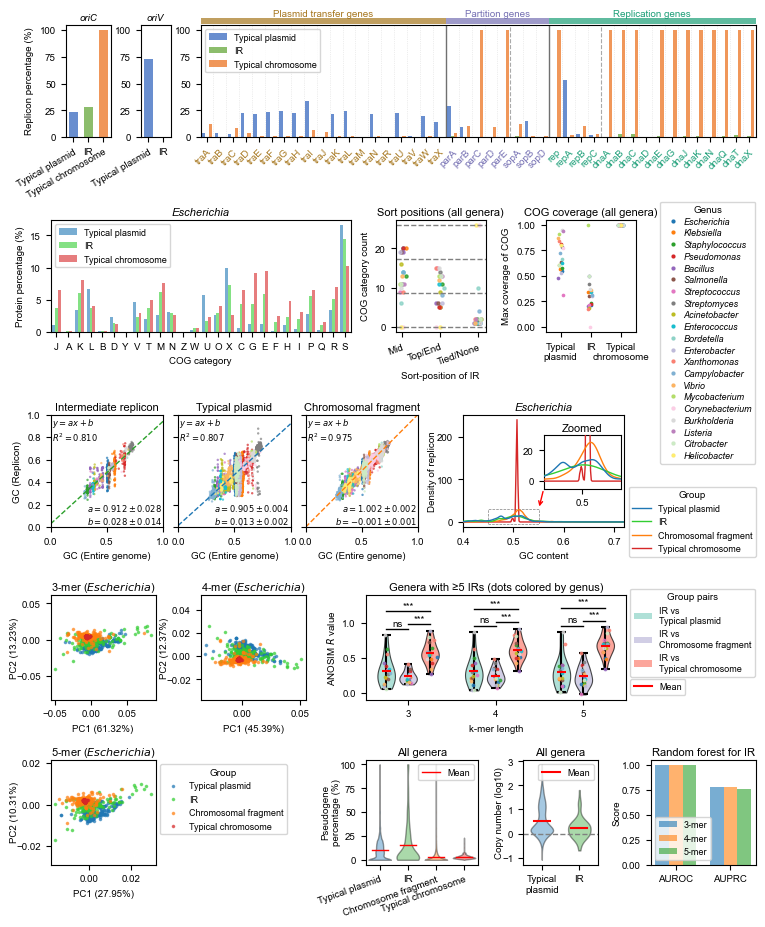

In [13]:
fig = plt.figure(figsize=(7.5, 7.5))

rep_y_site = 1 - 0.17
ax_oriC = fig.add_axes([0.08, rep_y_site, 0.06, 0.15])
ax_oriV = fig.add_axes([0.18, rep_y_site, 0.04, 0.15])
ax_gene_content = fig.add_axes([0.26, rep_y_site, 1-0.26, 0.15])
genus_name = 'Escherichia'
cats, oriC_data, oriV_data = get_ori_data(base_folder, genus_name, label)
plot_oriC(ax_oriC, oriC_data, cats)
plot_oriV(ax_oriV, oriV_data)
genes, t_data, tr_data, c_data = get_gene_data(base_folder, genus_name)
plot_gene_content(ax_gene_content, genes, t_data, tr_data, c_data, ifont_name)

color_list = list(plt.cm.tab10(np.linspace(0, 1, 10)))
set3_colors = list(plt.cm.Set3(np.linspace(0, 1, 12)))
set3_colors.pop(1)
color_list.extend(set3_colors)
genus_color_map = dict(zip(keep_genus, color_list[:len(keep_genus)]))

cog_cat_x_site = 0
cog_cat_y_site = rep_y_site - 0.26
ax_cog_category = fig.add_axes([cog_cat_x_site+0.06, cog_cat_y_site, 0.4, 0.15])
genus_name = 'Escherichia'
cog_cat_result = cog_cat_data(genus_name, base_folder)
cog_cat_draw(ax_cog_category, cog_cat_result, genus_name)
ax_cog_category.legend()

rep_sort_x_site = 0.46
rep_sort_y_site = cog_cat_y_site
ax_rep_sort = fig.add_axes([rep_sort_x_site+0.06, rep_sort_y_site, 0.12, 0.15])
rep_sort_data = cog_rank_data(base_folder, keep_genus)
cog_rank_scatter(ax_rep_sort, rep_sort_data, genus_color_map)

cog_x_site = 0.66
cog_y_site = cog_cat_y_site
max_cog_coverage = cog_data(keep_genus, base_folder)
ax_cog_coverage = fig.add_axes([cog_x_site+0.06, cog_y_site, 0.12, 0.15])
cog_data_draw(ax_cog_coverage, max_cog_coverage, genus_color_map)

handles = []
labels = []
for genus in keep_genus:
    if genus in genus_color_map:
        handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor=genus_color_map[genus],
                                 markersize=3, markeredgecolor="black", markeredgewidth=0.01))
        labels.append(genus)

ax_cog_coverage.legend(handles, labels, title="Genus", loc="upper left", bbox_to_anchor=(1.22, 1.2), frameon=True, 
                      ncol=1, prop=ifont_prop_6, columnspacing=0.3, handletextpad=0.2, labelspacing=0.3)

tpy_MS, tra_MS, chr_frag_MS = GC_data(base_folder)
GC_size = 0.15
GC_x_site = 0
GC_y_site = cog_y_site - (GC_size + 0.08 + 0.03)
ax_tra_GC = fig.add_axes([GC_x_site + 0.06, GC_y_site, GC_size, GC_size])
ax_tpy_GC = fig.add_axes([GC_x_site + 0.06 + GC_size + 0.02, GC_y_site, GC_size, GC_size])
ax_chr_frag_GC = fig.add_axes([GC_x_site + 0.06 + (GC_size + 0.02)*2, GC_y_site, GC_size, GC_size])

GC_data_figure(ax_tra_GC, tra_MS, genus_color_map, replicon_type='intermediate replicon')
GC_data_figure(ax_tpy_GC, tpy_MS, genus_color_map, replicon_type='typical plasmid', y_label=False)
GC_data_figure(ax_chr_frag_GC, chr_frag_MS, genus_color_map, replicon_type='chromosomal fragment', y_label=False)

gc_curve_x_site = GC_x_site + 0.05 + (GC_size + 0.03)*2 + GC_size
gc_curve_y_site = GC_y_site
ax_Ec_gc_curve = fig.add_axes([gc_curve_x_site + 0.05, gc_curve_y_site, GC_size+0.065, GC_size])
data_groups = load_gc_data_groups(genus_name, base_folder)
plot_gc_density(ax_Ec_gc_curve, data_groups)
ax_Ec_gc_curve.legend(title='Group', bbox_to_anchor=(1, 0.4), loc='upper left')

# PCA_line

genus_name = 'Escherichia'
k_mer = ['3', '4', '5']
PCA_x_site = 0
PCA_y_site = GC_y_site - (0.2 + 0.03)
ax_PCA = {}
for i in range(len(k_mer)):
    ax_PCA[k_mer[i]] = fig.add_axes([PCA_x_site + 0.06 + (0.2)*(i%2), PCA_y_site - int(i/2)*(0.2 + 0.02), 0.14, 0.14])
    #ax_PCA[k_mer[i]] = fig.add_axes([PCA_x_site + 0.06 + (0.2 - 0.01)*i, PCA_y_site + 0.02, 0.12, 0.12])
    PCA_data = pd.read_csv(f'{base_folder}/figure_data/kmer_analysis_output/{genus_name}/{k_mer[i]}mer_pca_coords_repeat1.csv')
    PCA_scatter_plot(ax_PCA[k_mer[i]], PCA_data, genus_name)

ax_PCA['5'].legend(title='Group', loc="upper left", bbox_to_anchor=(1, 1), )

Es_R_x_stie = 0.48
ax_Es_R = fig.add_axes([Es_R_x_stie, PCA_y_site, 0.82+0.007-Es_R_x_stie, 0.14])

# data
data = []
for genus_name in keep_genus:
    temp_pd = pd.read_csv(f'{base_folder}/figure_data/kmer_analysis_output/{genus_name}/anosim_pairwise_results_5repeats.csv')
    temp_pd['genus'] = genus_name
    new_pd = temp_pd.groupby(by=["k", "group1", "group2"], as_index=False).agg(
        genus=("genus", "first"),
        R=("R", "mean"),
        P=("P", "first"),
        significant=("significant", "first")
    )
    PCA_data = pd.read_csv(f'{base_folder}/figure_data/kmer_analysis_output/{genus_name}/{k_mer[i]}mer_pca_coords_repeat1.csv')
    if len(PCA_data[PCA_data['group']=='intermediate replicon']) >= 5:
        data.append(new_pd)
data = pd.concat(data, ignore_index=True)
#data = data[data['genus'].isin(keep_genus[10:19])]
plot_violin_scatter(ax_Es_R, data, genus_color_map, set3_colors)
        
# Pseudogene_figure
Pseudo_x_site = Es_R_x_stie
Pseudo_y_site = PCA_y_site - (0.2 + 0.02)
ax_pseudogene = fig.add_axes([Pseudo_x_site, Pseudo_y_site, 0.15, 0.14])

draw_pseudogene_data(keep_genus, ax_pseudogene, label, genus_color_map)

article_id = ['PMID40603865', 'PMID40603299']
PCN1 = pd.read_csv(f'/active-data/analysis_results/chr_pla/reference_data/{article_id[0]}/Fig1BC-Source-Data.csv')
PCN1 = PCN1.rename(columns={'SeqID': 'Contig', 'PIRACopyNumber': 'PCN'})
PCN2 = pd.read_excel(f'/active-data/analysis_results/chr_pla/reference_data/{article_id[1]}/41467_2025_61202_MOESM3_ESM.xlsx', sheet_name=1)

data = get_all_pcn_data(keep_genus=keep_genus, PCN_target=PCN1, label=label)

PCN_x_site = Pseudo_x_site + 0.08 + 0.03+0.1
PCN_y_site = Pseudo_y_site
ax_copynumber = fig.add_axes([PCN_x_site, PCN_y_site, 0.1, 0.14])
plot_pcn_on_ax(ax_copynumber, data, label, genus_color_map)

ax_ml = fig.add_axes([PCN_x_site + 0.17, PCN_y_site, 1-(PCN_x_site + 0.17), 0.14])
plot_ml(ax_ml, auroc_data, auprc_data)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)
os.chdir(figure_fold)
plt.savefig(f"All_replicon_features.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"All_replicon_features.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()